In [1]:
# Standard imports
import pandas as pd
import sys 
import os
import seaborn as sns
import os
import shutil
import numpy as np

# Local imports
import analysis_functions

# Apply better style
analysis_functions.apply_heatmap_style()

In [2]:
# Define study
STUDY_NAME = "ext_oct_scan_end_of_collapse_round_16"
COLLIDER = "base_collider"
PARQUET_PATH = f"../scans/{STUDY_NAME}/da.parquet"
CONF_MAD_PATH = f"../scans/{STUDY_NAME}/{COLLIDER}/config.yaml"
CONF_COLLIDER_PATH = f"../scans/{STUDY_NAME}/{COLLIDER}/xtrack_0016/config.yaml"

# Load dataframe
df = pd.read_parquet(f"../scans/{STUDY_NAME}/da.parquet")

# Round all numbers to 3 decimals
df = df.round(3)

# Keep only relevant collider
df = df.reset_index(level=1)
df = df[df["name base collider"] == COLLIDER]

df

name base collider  \
beam  qx     qy     i_oct_b1                         
lhcb1 62.305 60.310 -600.000000      base_collider   
                    -581.632653      base_collider   
                    -526.530612      base_collider   
                    -508.163265      base_collider   
                    -489.795918      base_collider   
...                                            ...   
      62.329 60.334  226.530612      base_collider   
                     244.897959      base_collider   
                     263.265306      base_collider   
                     281.632653      base_collider   
                     300.000000      base_collider   

                                 normalized amplitude in xy-plane      qx  \
beam  qx     qy     i_oct_b1                                                
lhcb1 62.305 60.310 -600.000000                             4.031  62.305   
                    -581.632653                             4.000  62.305   
                    -526.530612                             4.094  62.305   
                    -508.163265                             4.062  62.305   
                    -489.795918                             4.000  62.305   
...                                                           ...     ...   
      62.329 60.334  226.530612                             4.000  62.329   
                     244.897959                             4.000  62.329   
                     263.265306                             4.000  62.329   
                     281.632653                             4.000  62.329   
                     300.000000                             4.000  62.329   

                                     qy   dqx   dqy  i_bunch  i_oct_b1  \
beam  qx     qy     i_oct_b1                                             
lhcb1 62.305 60.310 -600.000000  60.310  15.0  15.0    150.0  -600.000   
                    -581.632653  60.310  15.0  15.0    150.0  -581.633   
                    -526.530612  60.310  15.0  15.0    150.0  -526.531   
                    -508.163265  60.310  15.0  15.0    150.0  -508.163   
                    -489.795918  60.310  15.0  15.0    150.0  -489.796   
...                                 ...   ...   ...      ...       ...   
      62.329 60.334  226.530612  60.334  15.0  15.0    150.0   226.531   
                     244.897959  60.334  15.0  15.0    150.0   244.898   
                     263.265306  60.334  15.0  15.0    150.0   263.265   
                     281.632653  60.334  15.0  15.0    150.0   281.633   
                     300.000000  60.334  15.0  15.0    150.0   300.000   

                                 num_particles_per_bunch  
beam  qx     qy     i_oct_b1                              
lhcb1 62.305 60.310 -600.000000             2.200000e+11  
                    -581.632653             2.200000e+11  
                    -526.530612             2.200000e+11  
                    -508.163265             2.200000e+11  
                    -489.795918             2.200000e+11  
...                                                  ...  
      62.329 60.334  226.530612             2.200000e+11  
                     244.897959             2.200000e+11  
                     263.265306             2.200000e+11  
                     281.632653             2.200000e+11  
                     300.000000             2.200000e+11  

[1047 rows x 9 columns]

(np.float64(-600.0), np.float64(300.0), np.float64(62.329), np.float64(62.305))
24999.999999999054
Luminosity not found in config, setting to None


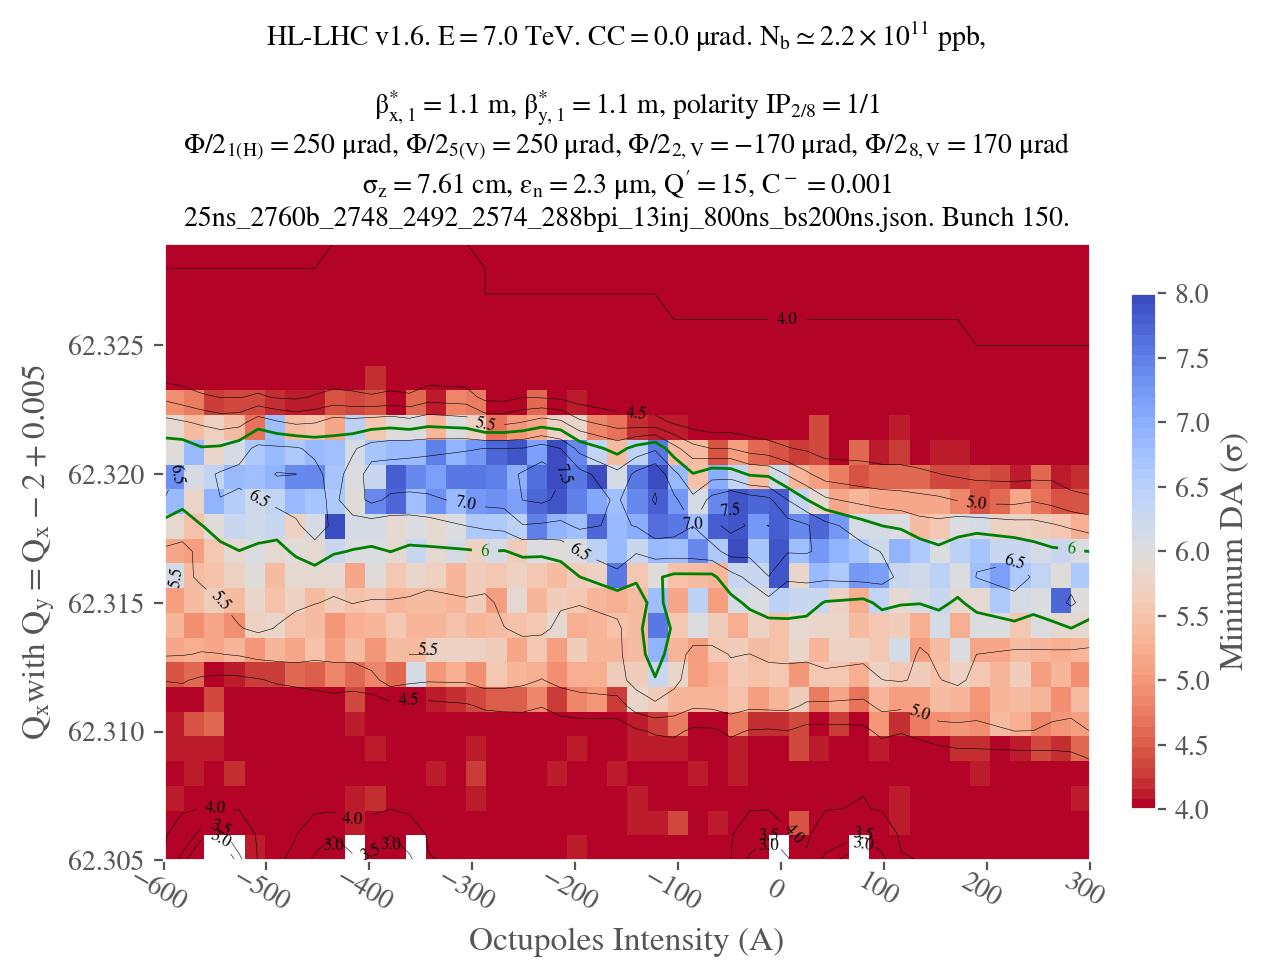

In [3]:
# Reshape for plotting
df_to_plot = df.pivot(index="qx", columns="i_oct_b1", values="normalized amplitude in xy-plane")

#l_oct = np.linspace(-300,300,25)+1
#l_oct = np.linspace(-600,300,50)
#df_to_plot = df_to_plot.reindex(columns=l_oct)
#df_to_plot.columns = [str(oct) for oct in l_oct]

# replace nan in df by 10
#df_to_plot = df_to_plot.fillna(10)
df_to_plot = df_to_plot.interpolate()


# Load configuration files
conf_mad = analysis_functions.load_config(CONF_MAD_PATH)['config_mad']
conf_collider = analysis_functions.load_config(CONF_COLLIDER_PATH)["config_collider"]

xlabel = "Octupoles Intensity (A)"
ylabel = r"$Q_x$" + "with " + r"$Q_y = Q_x -2 + 0.005$"
analysis_functions.plot_heatmap(
    df_to_plot,
    f'{STUDY_NAME}_{COLLIDER}',
    link=None,
    plot_contours=True,
    conf_mad=conf_mad,
    conf_collider=conf_collider,
    betx = 1.1,
    bety = 1.1,
    type_crossing="flathv",
    symmetric=False,
    mask_lower_triangle=False,
    xlabel=xlabel,
    ylabel=ylabel,
    plot_diagonal_lines=False,
    xaxis_ticks_on_top=False,
    display_intensity=False,
    green_contour=6.,
    CC = True,
    vmin=4.,
    vmax=8.0,
    extended_diagonal=False,
    Nb=True,
    #title="opt_collapse_1100_1500_oct_scan",
)

Luminosity not found in config, setting to None


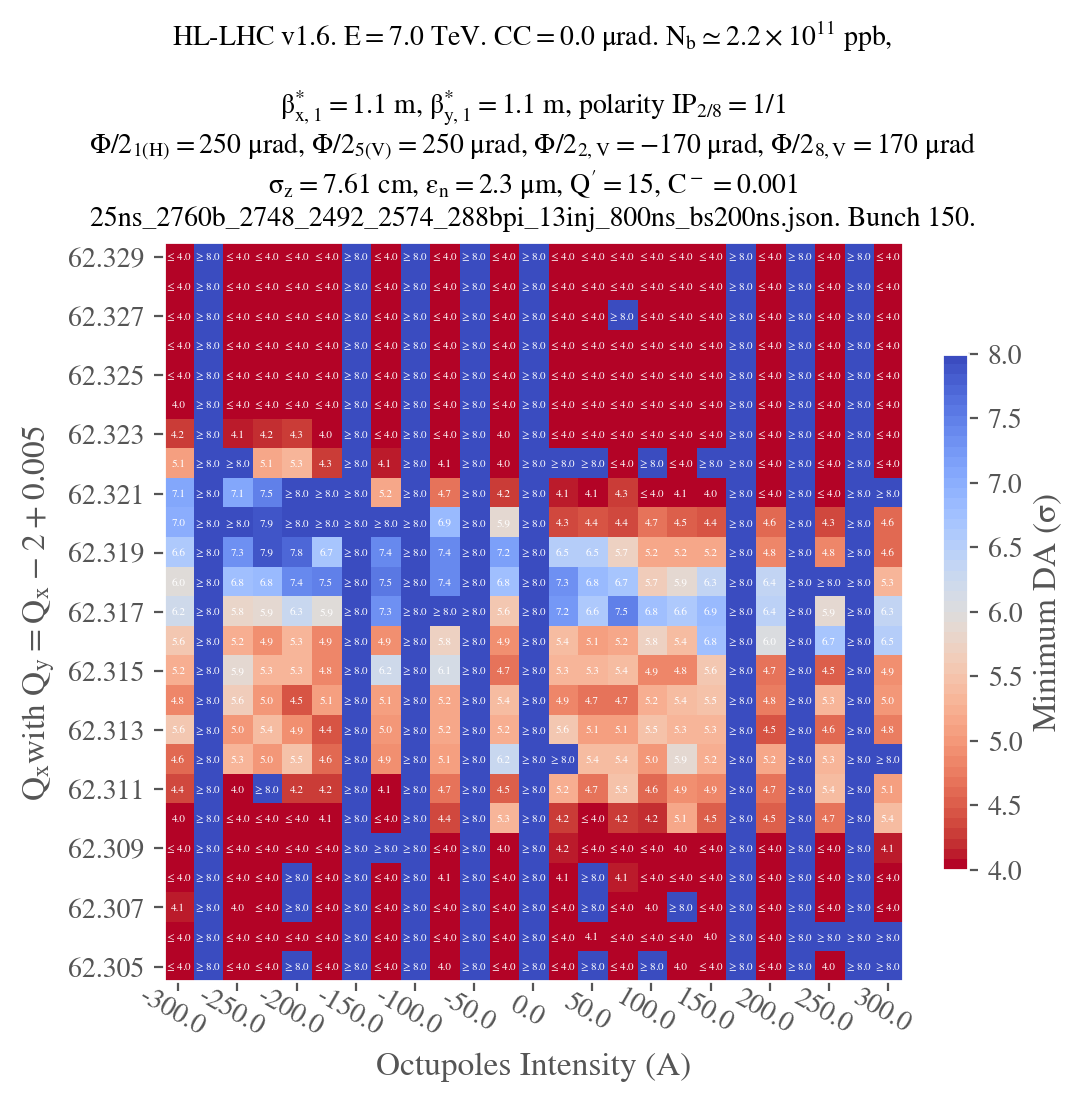

In [7]:
# Reshape for plotting
df_to_plot = df.pivot(index="qx", columns="i_oct_b1", values="normalized amplitude in xy-plane")

l_oct = np.linspace(-300,300,25)
df_to_plot = df_to_plot.reindex(columns=l_oct)
df_to_plot.columns = [str(oct) for oct in l_oct]

# replace nan in df by 10
df_to_plot = df_to_plot.fillna(10)


# Load configuration files
conf_mad = analysis_functions.load_config(CONF_MAD_PATH)['config_mad']
conf_collider = analysis_functions.load_config(CONF_COLLIDER_PATH)["config_collider"]

xlabel = "Octupoles Intensity (A)"
ylabel = r"$Q_x$" + "with " + r"$Q_y = Q_x -2 + 0.005$"
analysis_functions.plot_heatmap(
    df_to_plot,
    f'{STUDY_NAME}_{COLLIDER}',
    link=None,
    plot_contours=False,
    conf_mad=conf_mad,
    conf_collider=conf_collider,
    betx = 1.1,
    bety = 1.1,
    type_crossing="flathv",
    symmetric=False,
    mask_lower_triangle=False,
    xlabel=xlabel,
    ylabel=ylabel,
    plot_diagonal_lines=False,
    xaxis_ticks_on_top=False,
    display_intensity=False,
    green_contour=6.,
    CC = True,
    vmin=4.,
    vmax=8.0,
    extended_diagonal=False,
    Nb=True,
    #title="opt_collapse_1100_1500_oct_scan",
)